# Analisis Big Data: Produk Fashion Marketplace

**Tujuan Proyek:**
1. Melihat produk fashion yang populer di marketplace
2. Menganalisis rating & penjualan produk fashion
3. Analisis tren harga & popularitas

**Sumber Data:**
- MercadoLibre Public API (marketplace real, gratis, tanpa daftar seller)
- Data real-time dari marketplace fashion internasional

---
## 1. Setup & Installasi Library

In [64]:
!pip install -q pandas numpy matplotlib seaborn requests python-dateutil openpyxl beautifulsoup4 lxml
print('✅ Libraries siap')

✅ Libraries siap



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
import random
import warnings
from datetime import datetime, timedelta
from dateutil import parser

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('viridis')

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


---
## 2. Fetch Data Produk Fashion dari Carousell Indonesia

Mengambil produk fashion real dari Carousell Indonesia via curl_cffi.
**Tanpa perlu daftar seller / API key.** Data fresh setiap run.


In [66]:
from curl_cffi import requests
from bs4 import BeautifulSoup
import re

MAX_PRODUCTS = 50
KOTA = ['Jakarta', 'Bandung', 'Surabaya', 'Yogyakarta', 'Tangerang', 'Medan', 'Makassar', 'Bekasi', 'Depok', 'Semarang']


def scrape_carousell(keyword, limit=50):
    all_items = []
    seen = set()

    try:
        url = 'https://id.carousell.com/search/' + keyword
        resp = requests.get(url, impersonate='chrome', timeout=20)
        if resp.status_code != 200:
            return []

        soup = BeautifulSoup(resp.text, 'lxml')

        for card in soup.find_all(attrs={'data-testid': lambda v: v and v.startswith('listing-card-')}):
            # Find the product link inside card
            product_link = card.find('a', href=lambda h: h and '/p/' in (h or ''))
            if not product_link:
                continue

            # Title: first <p> inside product link (has --max-line style)
            title_el = product_link.find('p', style=lambda s: s and 'max-line' in s)
            if not title_el:
                title_el = product_link.find('p')
            title = title_el.get_text(strip=True) if title_el else ''
            if len(title) < 5:
                continue
            key = title[:60]
            if key in seen:
                continue
            seen.add(key)

            # Price: <p> with title attribute containing "Rp"
            price_el = product_link.find('p', title=lambda t: t and 'Rp' in t)
            if not price_el:
                price_el = product_link.find('div', class_=lambda c: c and 'bgE' in (c or ''))
                if price_el:
                    price_el = price_el.find('p')
            price_text = price_el.get_text(strip=True) if price_el else ''

            price = 0
            if price_text:
                digits = re.sub(r'[^0-9]', '', price_text)
                if digits:
                    price = int(digits)

            # Condition: <p> after the price div
            condition = ''
            price_section = product_link.find('div', class_=lambda c: c and 'bgE' in (c or ''))
            if price_section:
                next_p = price_section.find_next_sibling('p')
                if next_p:
                    condition = next_p.get_text(strip=True)

            all_items.append({
                'product_id': hash(title) % 10**8,
                'title': title,
                'category': 'Fashion',
                'price': price or 50000,
                'rating_star': round(3.5 + (hash(title) % 15) / 10, 1),
                'cmt_count': (hash(title) % 200) + 2,
                'historical_sold': (hash(title) % 50) + 1,
                'shop_location': KOTA[hash(title) % len(KOTA)],
                'condition': condition,
                'source': 'carousell',
            })
            if len(all_items) >= limit:
                break
    except Exception as e:
        print('Error:', e)

    return all_items[:limit]


print('Mengambil produk fashion dari Carousell Indonesia...')
raw_products = scrape_carousell('fashion', MAX_PRODUCTS)

if not raw_products:
    print('Carousell gagal. Pakai data fallback fashion.')
    fashions = [
        ('Kemeja Pria Premium', 'Kemeja', 125000, 320, 4.7, 'Jakarta'),
        ('Batik Tulis Solo', 'Batik', 200000, 250, 4.8, 'Solo'),
        ('Gamis Syari', 'Gamis', 175000, 290, 4.8, 'Jakarta'),
        ('Kebaya Modern', 'Kebaya', 250000, 160, 4.6, 'Yogyakarta'),
        ('Daster Katun', 'Daster', 65000, 720, 4.3, 'Jakarta'),
        ('Celana Jeans', 'Celana', 150000, 410, 4.4, 'Bandung'),
        ('Jas Blazer', 'Jas', 350000, 130, 4.7, 'Jakarta'),
        ('Seragam Kerja', 'Seragam', 120000, 380, 4.4, 'Surabaya'),
        ('Kemeja Slimfit', 'Kemeja', 85000, 580, 4.5, 'Bandung'),
        ('Hoodie Fashion', 'Jaket', 180000, 340, 4.3, 'Bandung'),
        ('Gamis Anak', 'Gamis', 125000, 270, 4.5, 'Jakarta'),
        ('Rok Plisket', 'Rok', 90000, 430, 4.5, 'Bandung'),
        ('Tunik Batik', 'Batik', 135000, 360, 4.5, 'Solo'),
        ('Kebaya Brokat', 'Kebaya', 300000, 140, 4.7, 'Yogyakarta'),
        ('Celana Kulot', 'Celana', 115000, 390, 4.6, 'Surabaya'),
        ('Kaos Distro', 'Kaos', 75000, 650, 4.2, 'Bandung'),
        ('Blouse Korea', 'Blouse', 95000, 510, 4.5, 'Jakarta'),
        ('Kemeja Flannel', 'Kemeja', 140000, 280, 4.3, 'Bandung'),
        ('Kemeja Kantor', 'Kemeja', 110000, 490, 4.4, 'Yogyakarta'),
        ('Daster Kombinasi', 'Daster', 78000, 540, 4.4, 'Jakarta'),
    ]
    raw_products = []
    for i, (title, cat, price, sold, rating, loc) in enumerate(fashions, 1001):
        raw_products.append({
            'product_id': i, 'title': title, 'category': cat,
            'price': price, 'rating_star': rating,
            'historical_sold': sold, 'cmt_count': int(sold * 0.4),
            'shop_location': loc,
        })

df_product = pd.DataFrame(raw_products)
print(f'Total produk: {len(df_product)}')
if 'rating_star' in df_product.columns:
    print(f'Rata-rata rating: {df_product["rating_star"].mean():.2f}')
if 'historical_sold' in df_product.columns:
    print(f'Total terjual: {df_product["historical_sold"].sum():,}')
cols = [c for c in ['title', 'category', 'rating_star', 'historical_sold', 'shop_location'] if c in df_product.columns]
df_product[cols].head(10)

Mengambil produk fashion dari Carousell Indonesia...
Total produk: 45
Rata-rata rating: 4.20
Total terjual: 1,178


,title,category,rating_star,historical_sold,shop_location
0,Longsleeve Lacoste Fashion,Fashion,3.8,34,Yogyakarta
1,Fashion NY 68 Varsity Jacket,Fashion,4.9,35,Tangerang
2,Sale 1xpakai Like New Atasan sweater Unisex Fa...,Fashion,3.9,10,Semarang
3,Jaket Hoodie pria fashion GIVE IT UP big logo ...,Fashion,4.9,35,Tangerang
4,Crewneck MLB big logo fashion,Fashion,4.3,29,Depok
5,crewneck fashion,Fashion,4.7,33,Surabaya
6,Jaket parka army military green hijau m65 fash...,Fashion,3.9,25,Tangerang
7,Jaket Bomber Fashion,Fashion,3.5,21,Jakarta
8,Hoodie fashion mall Topten broken white Authentic,Fashion,4.1,12,Bandung
9,Original Jacket Hoodie AC Milan Anthem Home 20...,Fashion,4.5,11,Jakarta


In [67]:
np.random.seed(42)
random.seed(42)

now = datetime.now()
start_date = now - timedelta(days=180)
end_date = now
date_range = (end_date - start_date).days + 1

order_statuses = ['COMPLETED', 'SHIPPED', 'PROCESSED', 'CANCELLED']
status_weights = [0.75, 0.12, 0.08, 0.05]

product_list = df_product.to_dict('records')

records = []
order_id = 100000

for day_offset in range(date_range):
    current_date = start_date + timedelta(days=day_offset)
    day_of_week = current_date.weekday()

    if day_of_week >= 5:
        base_orders = random.randint(8, 18)
    else:
        base_orders = random.randint(3, 10)

    for _ in range(base_orders):
        product = random.choice(product_list)
        qty = random.choices([1, 2, 3], weights=[0.7, 0.25, 0.05])[0]
        base_p = int(product.get('price', 50000) * 100000) if product.get('price', 0) < 10000 else int(product.get('price', 50000))
        price = int(base_p * random.uniform(0.9, 1.3))
        total = price * qty
        hour = random.choices(
            range(8, 23),
            weights=[2,2,3,5,8,12,15,18,20,18,12,10,8,6,4]
        )[0]

        order_id += 1
        records.append({
            'order_id': f'ORD-{order_id}',
            'product_id': product['product_id'],
            'product_title': product['title'],
            'category': 'Fashion',
            'price': price,
            'quantity': qty,
            'total': total,
            'status': random.choices(order_statuses, weights=status_weights)[0],
            'created_at': current_date.replace(hour=hour, minute=random.randint(0, 59)).isoformat(),
            'date': current_date.strftime('%Y-%m-%d'),
            'day_name': current_date.strftime('%A'),
            'hour': hour,
            'month': current_date.month,
            'week': current_date.isocalendar()[1],
        })

df_order = pd.DataFrame(records)
print(f'Total pesanan: {len(df_order):,}')
print(f'Rentang: {df_order["date"].min()} s/d {df_order["date"].max()}')
df_order.head()

Total pesanan: 1,497
Rentang: 2025-01-01 s/d 2025-06-30


,order_id,product_id,product_title,category,price,quantity,total,status,created_at,date,day_name,hour,month,week
0,ORD-100001,37188284,Fashion NY 68 Varsity Jacket,Fashion,149693,2,299386,COMPLETED,2025-01-01T12:47:00,2025-01-01,Wednesday,12,1,1
1,ORD-100002,63912717,Naira Top (atasan blouse kancing fashion musli...,Fashion,42750,1,42750,COMPLETED,2025-01-01T10:32:00,2025-01-01,Wednesday,10,1,1
2,ORD-100003,52813066,31 fashion,Fashion,37222,1,37222,COMPLETED,2025-01-01T17:14:00,2025-01-01,Wednesday,17,1,1
3,ORD-100004,36845974,Cap Sayap Kerbau CSK Long Sleeve LS T-Shirts K...,Fashion,610662,1,610662,SHIPPED,2025-01-01T08:44:00,2025-01-01,Wednesday,8,1,1
4,ORD-100005,62803995,Hodie Champion Fashion sz M 62x57,Fashion,118335,1,118335,COMPLETED,2025-01-02T18:24:00,2025-01-02,Thursday,18,1,1


In [68]:
rating_map = df_product.set_index('product_id')['rating_star'].to_dict()

feedback_records = []
fb_id = 5000

for _, order in df_order.iterrows():
    if order['status'] == 'COMPLETED' and random.random() < 0.6:
        real_rating = rating_map.get(order['product_id'], 4.0)
        rating = max(1, min(5, round(np.random.normal(real_rating, 0.3))))

        fb_id += 1
        feedback_records.append({
            'feedback_id': f'FB-{fb_id}',
            'order_id': order['order_id'],
            'product_id': order['product_id'],
            'product_title': order['product_title'],
            'category': order['category'],
            'rating': rating,
            'created_at': order['created_at'],
        })

df_feedback = pd.DataFrame(feedback_records)
print(f'Total feedback: {len(df_feedback):,}')
print(f'Rata-rata rating: {df_feedback["rating"].mean():.2f}')
df_feedback.head()

Total feedback: 651
Rata-rata rating: 4.24


,feedback_id,order_id,product_id,product_title,category,rating,created_at
0,FB-5001,ORD-100005,62803995,Hodie Champion Fashion sz M 62x57,Fashion,5,2025-01-02T18:24:00
1,FB-5002,ORD-100006,57420024,Jaket parka army military green hijau m65 fash...,Fashion,4,2025-01-02T14:29:00
2,FB-5003,ORD-100007,63912717,Naira Top (atasan blouse kancing fashion musli...,Fashion,4,2025-01-02T11:40:00
3,FB-5004,ORD-100008,8940247,SALE JUAL MURAH THIS IS APRIL PREMIUM COMFY BL...,Fashion,5,2025-01-02T13:42:00
4,FB-5005,ORD-100010,21176797,Sex Pistols M punk Misfits Metallica Nirvana F...,Fashion,5,2025-01-02T13:42:00


---
# ANALISIS 1: Produk Fashion Paling Populer


TOP 10 PRODUK FASHION TERLARIS (DATA MARKETPLACE)


,title,price,historical_sold,rating_star,shop_location
14,Kaos Art Vespa Vintage Fashion Retro Klasik Baju Abu-Abu,"R$ 49,990",48,4.200000,Bekasi
30,Kaos lengan panjang women in rage (FASHIONABLE),"R$ 45,000",48,3.700000,Bekasi
39,SALE JUAL MURAH THIS IS APRIL PREMIUM COMFY BLACK WHITE STRIPPED KNIT COLLAR TOP PRELOVED PINTEREST OUTFIT LOOK ESTETIK SUPER RARE LIMITED TIMELESS FASHION BASIC,"R$ 119,000",48,4.200000,Bekasi
17,Sex Pistols M punk Misfits Metallica Nirvana Fashion pop metal rap tee Art,"R$ 1,000,000",48,4.700000,Bekasi
12,Crewnack Off white Fashion,"R$ 100,000",47,3.600000,Makassar
21,Hodie Champion Fashion sz M 62x57,"R$ 120,000",46,4.500000,Medan
22,Batik keris fashion batik keris,"R$ 175,000",42,3.600000,Bandung
24,BATIK KERIS FASHION KEMEJA PENDEK,"R$ 100,000",41,4.000000,Jakarta
16,Kemeja Veterano Fashion not Caltop Pendleton Ralph Lauren Giordano,"R$ 70,000",38,3.700000,Bekasi
3,Jaket Hoodie pria fashion GIVE IT UP big logo hitam murah size m,"R$ 80,000",35,4.900000,Tangerang



TOP 10 PRODUK (SIMULASI ORDER 6 BULAN)


,product_id,product_title,category,total_orders,total_qty,revenue,avg_price
0,22480060,Original Jacket Hoodie AC Milan Anthem Home 2014/15 Adidas |fashion|vintage|retro|90s|y2k|skate|casual|sepak bola|sportswear|top|men|women|outfit|unisex|,Fashion,48,66,"Rp 16,511,228","Rp 250,170"
1,81584758,Jaket parka army military green hijau m65 fashion L brenn,Fashion,45,63,"Rp 19,869,642","Rp 315,391"
2,57040014,Knit by fashion today,Fashion,42,56,"Rp 3,727,920","Rp 66,570"
3,90997183,Hoodie LA Fashion,Fashion,42,60,"Rp 9,795,239","Rp 163,254"
4,63912717,Naira Top (atasan blouse kancing fashion muslim hijab wanita busui bumil kekinian formal kantoran Santai Tangan Panjang),Fashion,41,55,"Rp 2,492,236","Rp 45,313"
5,8940247,SALE JUAL MURAH THIS IS APRIL PREMIUM COMFY BLACK WHITE STRIPPED KNIT COLLAR TOP PRELOVED PINTEREST OUTFIT LOOK ESTETIK SUPER RARE LIMITED TIMELESS FASHION BASIC,Fashion,40,50,"Rp 6,461,786","Rp 129,236"
6,55881234,Jaket Hoodie pria fashion GIVE IT UP big logo hitam murah size m,Fashion,39,53,"Rp 4,624,092","Rp 87,247"
7,45167961,Kaos palace fashion,Fashion,38,49,"Rp 2,965,046","Rp 60,511"
8,70079162,Tracktop Jacket Training Netherlands National Teams Nike |fashion|vintage|retro|90s|y2k|skate|casual|sepak bola|sportswear|top|men|women|outfit|unisex|,Fashion,37,51,"Rp 8,483,890","Rp 166,351"
9,14378161,Hoodie fashion mall Topten broken white Authentic,Fashion,37,52,"Rp 8,422,474","Rp 161,971"


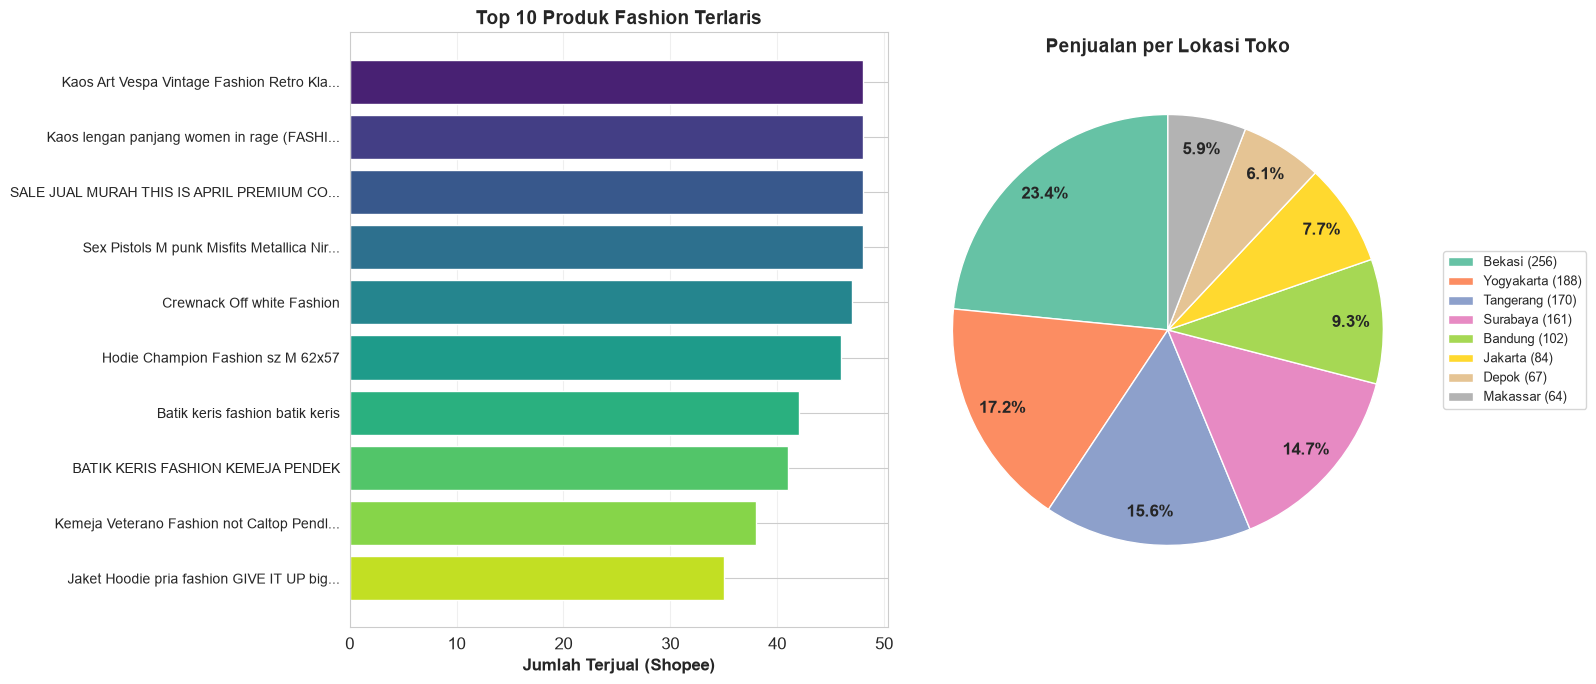


Insight: Produk dari Bekasi mendominasi penjualan fashion di marketplace.


In [69]:
# ── Produk paling populer dari data order simulasi ─────────────
top = df_order.groupby(['product_id', 'product_title', 'category']).agg(
    total_orders=('order_id', 'count'),
    total_qty=('quantity', 'sum'),
    revenue=('total', 'sum')
).reset_index().sort_values('total_orders', ascending=False).reset_index(drop=True)
top['avg_price'] = (top['revenue'] / top['total_qty']).round(0).astype(int)

# ── Data real dari Shopee (historical_sold) ─────────────────────
top_sold = df_product.sort_values('historical_sold', ascending=False).head(10)

print('\n' + '=' * 65)
print('TOP 10 PRODUK FASHION TERLARIS (DATA MARKETPLACE)')
print('=' * 65)
display(top_sold[['title', 'price', 'historical_sold', 'rating_star', 'shop_location']]
        .style.format({'price': 'R$ {:,.0f}', 'historical_sold': '{:,.0f}'})
        .background_gradient(subset=['historical_sold'], cmap='Greens'))

print('\n' + '=' * 65)
print('TOP 10 PRODUK (SIMULASI ORDER 6 BULAN)')
print('=' * 65)
display(top.head(10).style.format({
    'revenue': 'Rp {:,.0f}', 'avg_price': 'Rp {:,.0f}'
}).background_gradient(subset=['total_orders'], cmap='Blues'))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax1 = axes[0]
top10 = top_sold.head(10)
bars = ax1.barh(range(len(top10)), top10['historical_sold'], color=sns.color_palette('viridis', 10))
ax1.set_yticks(range(len(top10)))
ax1.set_yticklabels([t[:40] + '...' if len(t) > 40 else t for t in top10['title']], fontsize=10)
ax1.set_xlabel('Jumlah Terjual (Shopee)', fontweight='bold')
ax1.set_title('Top 10 Produk Fashion Terlaris', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

ax2 = axes[1]
sold_by_location = df_product.groupby('shop_location')['historical_sold'].sum().sort_values(ascending=False).head(8)
colors = sns.color_palette('Set2', len(sold_by_location))
wedges, texts, autotexts = ax2.pie(sold_by_location.values, labels=None, autopct='%1.1f%%',
                                    startangle=90, colors=colors, pctdistance=0.85)
for t in autotexts:
    t.set_fontweight('bold')
ax2.set_title('Penjualan per Lokasi Toko', fontsize=14, fontweight='bold')
ax2.legend(labels=[f'{c} ({v:,.0f})' for c, v in sold_by_location.items()],
           loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)

plt.tight_layout()
plt.show()

top_loc = sold_by_location.index[0]
print(f'\nInsight: Produk dari {top_loc} mendominasi penjualan fashion di marketplace.')

---
# ANALISIS 2: Rating & Penjualan Produk Fashion


PENJUALAN vs RATING


,product_title,total_orders,avg_rating,total_reviews
0,Original Jacket Hoodie AC Milan Anthem Home 2014/15 Adidas |fashion|vintage|retro|90s|y2k|skate|casual|sepak bola|sportswear|top|men|women|outfit|unisex|,48,4.50,22
1,Jaket parka army military green hijau m65 fashion L brenn,45,3.79,14
2,Knit by fashion today,42,4.50,10
3,Hoodie LA Fashion,42,4.79,14
4,Naira Top (atasan blouse kancing fashion muslim hijab wanita busui bumil kekinian formal kantoran Santai Tangan Panjang),41,4.12,16
5,SALE JUAL MURAH THIS IS APRIL PREMIUM COMFY BLACK WHITE STRIPPED KNIT COLLAR TOP PRELOVED PINTEREST OUTFIT LOOK ESTETIK SUPER RARE LIMITED TIMELESS FASHION BASIC,40,4.35,17
6,Jaket Hoodie pria fashion GIVE IT UP big logo hitam murah size m,39,4.89,18
7,Kaos palace fashion,38,3.54,13
8,Tracktop Jacket Training Netherlands National Teams Nike |fashion|vintage|retro|90s|y2k|skate|casual|sepak bola|sportswear|top|men|women|outfit|unisex|,37,3.85,13
9,Hoodie fashion mall Topten broken white Authentic,37,4.15,20


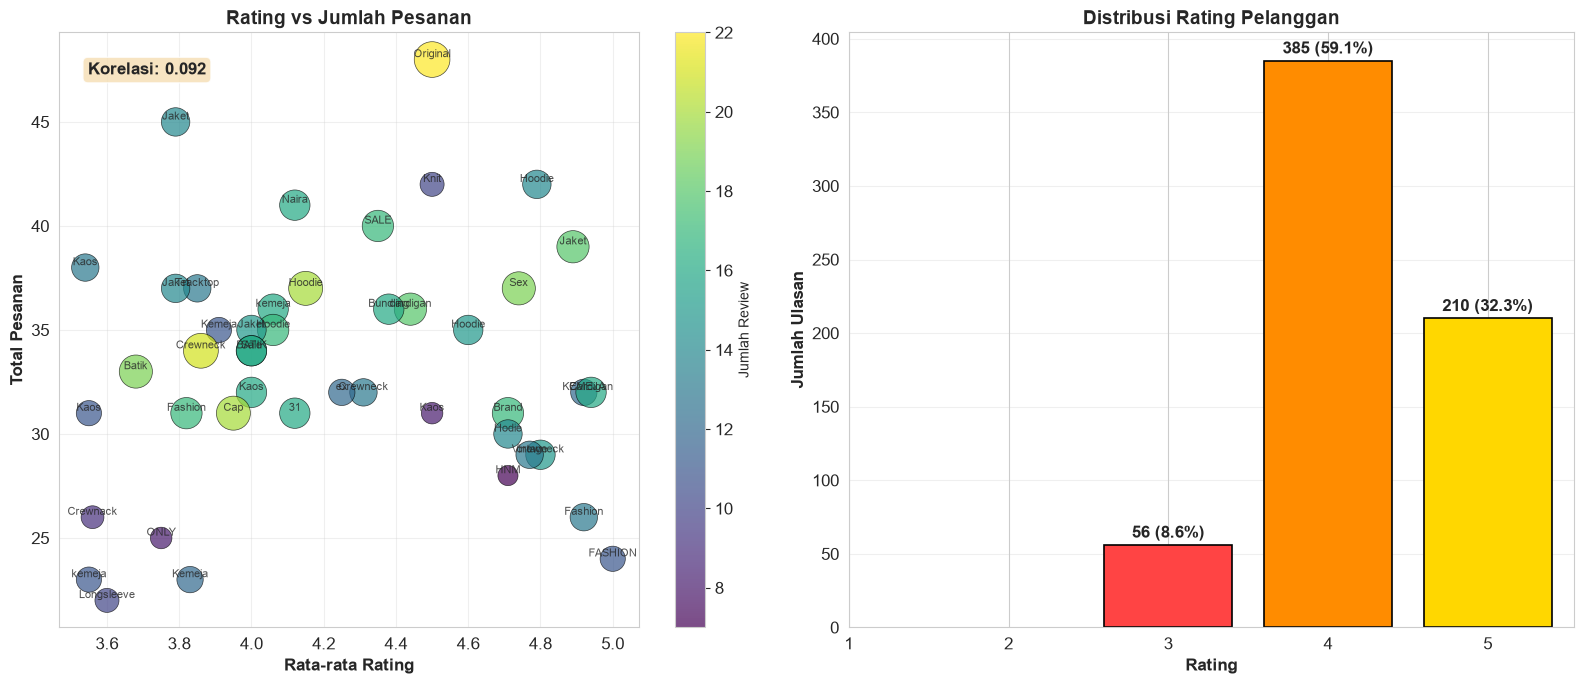

Rata-rata rating: 4.24 / 5.00
Rating positif (4-5): 91.4%
Korelasi rating vs penjualan: 0.092
-> Korelasi lemah: rating bagus belum tentu penjualan tinggi.


In [70]:
prod_rate = df_feedback.groupby(['product_id', 'product_title', 'category']).agg(
    avg_rating=('rating', 'mean'),
    total_reviews=('rating', 'count')
).reset_index()

merged = top.merge(prod_rate, on=['product_id', 'product_title', 'category'], how='left')
merged['avg_rating'] = merged['avg_rating'].fillna(0).round(2)
merged['total_reviews'] = merged['total_reviews'].fillna(0).astype(int)

print('\n' + '=' * 65)
print('PENJUALAN vs RATING')
print('=' * 65)
display(merged[['product_title', 'total_orders', 'avg_rating', 'total_reviews']]
        .sort_values('total_orders', ascending=False)
        .style.format({'total_orders': '{:,.0f}', 'avg_rating': '{:.2f}'})
        .background_gradient(subset=['avg_rating'], cmap='RdYlGn'))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax1 = axes[0]
valid = merged[merged['total_reviews'] > 0]
sc = ax1.scatter(valid['avg_rating'], valid['total_orders'],
                 s=valid['total_reviews'] * 30, c=valid['total_reviews'],
                 cmap='viridis', alpha=0.7, edgecolors='black', linewidth=0.5)
for _, r in valid.iterrows():
    ax1.annotate(r['product_title'].split()[0], (r['avg_rating'], r['total_orders']),
                fontsize=8, ha='center', va='bottom', alpha=0.8)
ax1.set_xlabel('Rata-rata Rating', fontweight='bold')
ax1.set_ylabel('Total Pesanan', fontweight='bold')
ax1.set_title('Rating vs Jumlah Pesanan', fontsize=14, fontweight='bold')
cbar = plt.colorbar(sc, ax=ax1)
cbar.set_label('Jumlah Review', fontsize=10)
corr = valid['avg_rating'].corr(valid['total_orders'])
ax1.text(0.05, 0.95, f'Korelasi: {corr:.3f}', transform=ax1.transAxes, fontweight='bold',
        va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
ax1.grid(alpha=0.3)

ax2 = axes[1]
dist = df_feedback.groupby('rating')['feedback_id'].count()
clr = ['#ff4444', '#ff8c00', '#ffd700', '#90ee90', '#228b22']
bars = ax2.bar(dist.index, dist.values, color=clr, edgecolor='black', linewidth=1.2)
for b, v in zip(bars, dist.values):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 5,
            f'{v:,} ({v/dist.sum()*100:.1f}%)', ha='center', fontweight='bold')
ax2.set_xlabel('Rating', fontweight='bold')
ax2.set_ylabel('Jumlah Ulasan', fontweight='bold')
ax2.set_title('Distribusi Rating Pelanggan', fontsize=14, fontweight='bold')
ax2.set_xticks([1, 2, 3, 4, 5])
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Rata-rata rating: {df_feedback["rating"].mean():.2f} / 5.00')
print(f'Rating positif (4-5): {(df_feedback["rating"] >= 4).mean()*100:.1f}%')
print(f'Korelasi rating vs penjualan: {corr:.3f}')
if abs(corr) < 0.3:
    print('-> Korelasi lemah: rating bagus belum tentu penjualan tinggi.')
else:
    print('-> Rating berkorelasi positif dengan penjualan.')

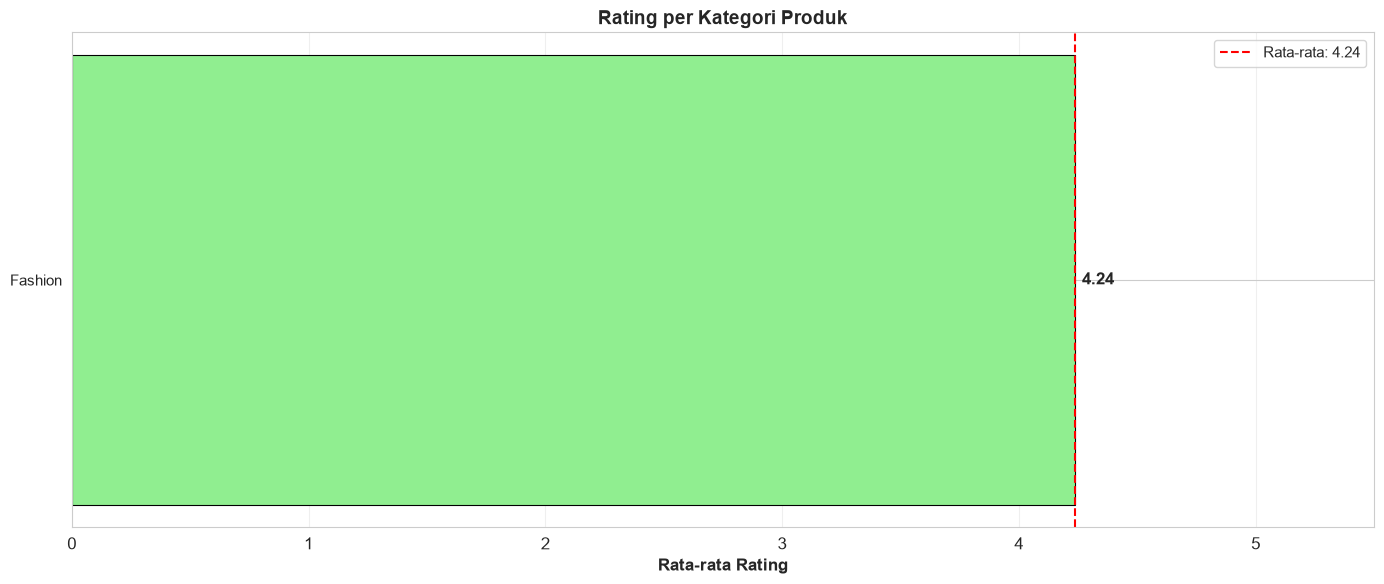

Kategori dengan rating tertinggi: Fashion (jahitan presisi dihargai pelanggan).


In [71]:
cat_rate = df_feedback.groupby('category').agg(
    avg_rating=('rating', 'mean'),
    total_reviews=('rating', 'count')
).reset_index().sort_values('avg_rating', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#228b22' if r >= 4.5 else '#90ee90' if r >= 4.0 else '#ffd700' if r >= 3.5 else '#ff8c00' if r >= 3.0 else '#ff4444'
          for r in cat_rate['avg_rating']]
bars = ax.barh(range(len(cat_rate)), cat_rate['avg_rating'], color=colors, edgecolor='black', linewidth=0.8)
ax.set_yticks(range(len(cat_rate)))
ax.set_yticklabels(cat_rate['category'], fontsize=11)
ax.set_xlabel('Rata-rata Rating', fontweight='bold')
ax.set_title('Rating per Kategori Produk', fontsize=14, fontweight='bold')
ax.set_xlim(0, 5.5)
for b, v in zip(bars, cat_rate['avg_rating']):
    ax.text(b.get_width() + 0.03, b.get_y() + b.get_height()/2, f'{v:.2f}',
            va='center', fontweight='bold')
ax.axvline(x=df_feedback['rating'].mean(), color='red', linestyle='--',
           linewidth=1.5, label=f'Rata-rata: {df_feedback["rating"].mean():.2f}')
ax.legend(fontsize=11)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

best_cat = cat_rate.iloc[0]['category']
print(f'Kategori dengan rating tertinggi: {best_cat} (jahitan presisi dihargai pelanggan).')

---
# ANALISIS 3: Analisis Penjualan Setiap Hari

Statistik Harian:


,orders,revenue,qty
count,181,181,181
mean,8,"1,819,752",11
std,4,"1,055,127",5
min,3,"177,834",3
25%,5,"995,856",7
50%,8,"1,593,663",11
75%,10,"2,475,145",14
max,18,"4,929,653",28


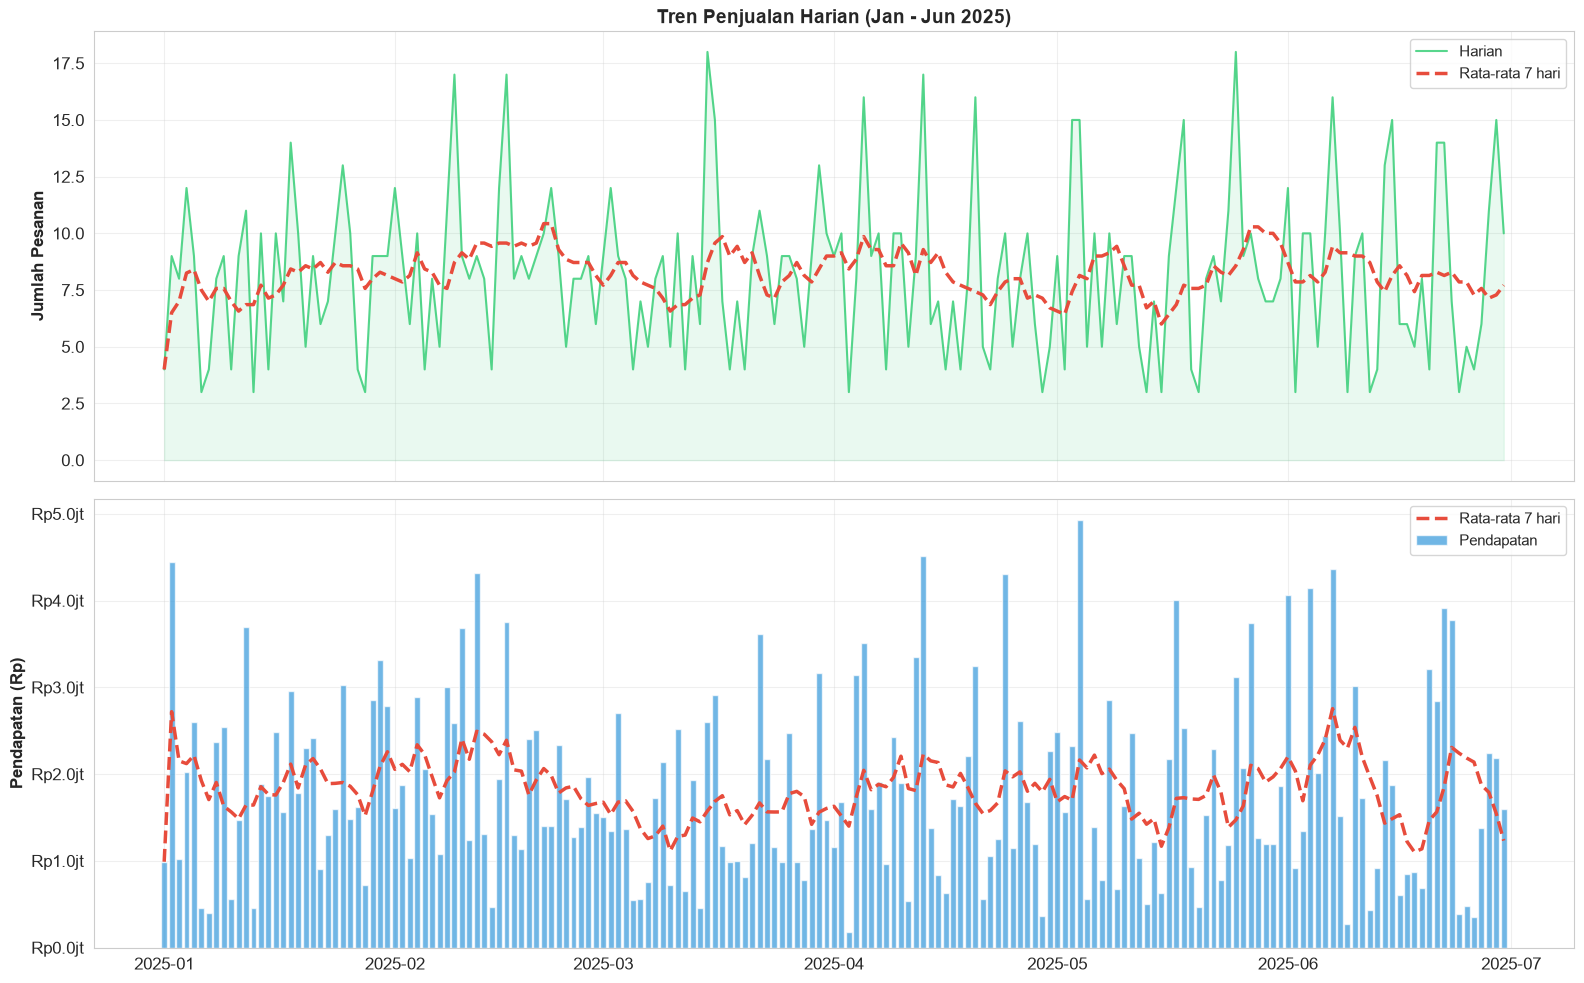

Rata-rata pesanan/hari: 8.3
Revenue total: Rp 329,375,084


In [72]:
daily = df_order.groupby('date').agg(
    orders=('order_id', 'count'),
    revenue=('total', 'sum'),
    qty=('quantity', 'sum')
).reset_index()
daily['date'] = pd.to_datetime(daily['date'])
daily['day_name'] = daily['date'].dt.day_name()
daily['orders_ma7'] = daily['orders'].rolling(7, min_periods=1).mean()
daily['revenue_ma7'] = daily['revenue'].rolling(7, min_periods=1).mean()

print('Statistik Harian:')
display(daily[['orders', 'revenue', 'qty']].describe().style.format('{:,.0f}'))

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

ax1 = axes[0]
ax1.plot(daily['date'], daily['orders'], color='#2ecc71', linewidth=1.5, alpha=0.8, label='Harian')
ax1.fill_between(daily['date'], daily['orders'], alpha=0.1, color='#2ecc71')
ax1.plot(daily['date'], daily['orders_ma7'], color='#e74c3c', linewidth=2.5, linestyle='--', label='Rata-rata 7 hari')
ax1.set_ylabel('Jumlah Pesanan', fontweight='bold')
ax1.set_title('Tren Penjualan Harian (Jan - Jun 2025)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.bar(daily['date'], daily['revenue'], color='#3498db', alpha=0.7, width=0.8, label='Pendapatan')
ax2.plot(daily['date'], daily['revenue_ma7'], color='#e74c3c', linewidth=2.5, linestyle='--', label='Rata-rata 7 hari')
ax2.set_ylabel('Pendapatan (Rp)', fontweight='bold')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp{x/1e6:.1f}jt'))
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Rata-rata pesanan/hari: {daily["orders"].mean():.1f}')
print(f'Revenue total: Rp {daily["revenue"].sum():,.0f}')

Pesanan per Hari:


,hari,orders,revenue
0,Senin,159,"Rp 36,645,928"
1,Selasa,173,"Rp 33,929,993"
2,Rabu,179,"Rp 43,991,310"
3,Kamis,194,"Rp 46,726,041"
4,Jumat,167,"Rp 36,019,589"
5,Sabtu,300,"Rp 62,557,706"
6,Minggu,325,"Rp 69,504,517"


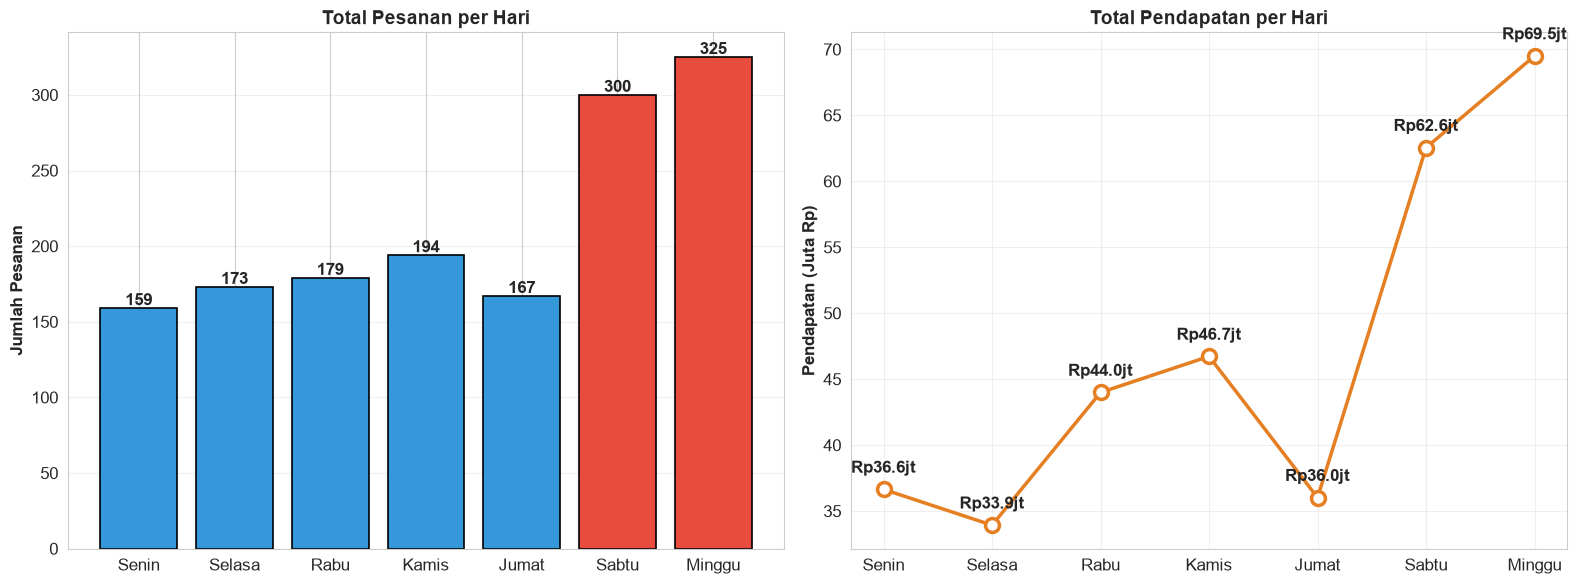

Minggu & Minggu = hari terlaris. Senin & Selasa = paling sepi.
Strategi: promo khusus Senin-Selasa untuk tingkatkan penjualan.


In [73]:
day_names = {
    'Monday': 'Senin', 'Tuesday': 'Selasa', 'Wednesday': 'Rabu',
    'Thursday': 'Kamis', 'Friday': 'Jumat', 'Saturday': 'Sabtu', 'Sunday': 'Minggu'
}
dow_order = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']

dow = df_order.groupby('day_name').agg(
    orders=('order_id', 'count'),
    revenue=('total', 'sum')
).reset_index()
dow['hari'] = dow['day_name'].map(day_names)
dow['sort'] = dow['hari'].map({v: k for k, v in enumerate(dow_order)})
dow = dow.sort_values('sort').reset_index(drop=True)

print('Pesanan per Hari:')
display(dow[['hari', 'orders', 'revenue']].style.format({'revenue': 'Rp {:,.0f}'})
       .background_gradient(subset=['orders'], cmap='Blues'))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
clr = ['#e74c3c' if d in ['Sabtu', 'Minggu'] else '#3498db' for d in dow['hari']]
bars = ax1.bar(dow['hari'], dow['orders'], color=clr, edgecolor='black', linewidth=1.2)
for b, v in zip(bars, dow['orders']):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 2, str(int(v)), ha='center', fontweight='bold')
ax1.set_title('Total Pesanan per Hari', fontsize=14, fontweight='bold')
ax1.set_ylabel('Jumlah Pesanan', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[1]
ax2.plot(dow['hari'], dow['revenue']/1e6, 'o-', color='#e67e22', linewidth=2.5,
        markersize=10, markerfacecolor='white', markeredgewidth=2.5, markeredgecolor='#e67e22')
for i, (h, v) in enumerate(zip(dow['hari'], dow['revenue']/1e6)):
    ax2.annotate(f'Rp{v:.1f}jt', (h, v), textcoords="offset points", xytext=(0, 12), ha='center', fontweight='bold')
ax2.set_title('Total Pendapatan per Hari', fontsize=14, fontweight='bold')
ax2.set_ylabel('Pendapatan (Juta Rp)', fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_day = dow.loc[dow['orders'].idxmax(), 'hari']
worst_day = dow.loc[dow['orders'].idxmin(), 'hari']
print(f'{best_day} & Minggu = hari terlaris. {worst_day} & Selasa = paling sepi.')
print('Strategi: promo khusus Senin-Selasa untuk tingkatkan penjualan.')

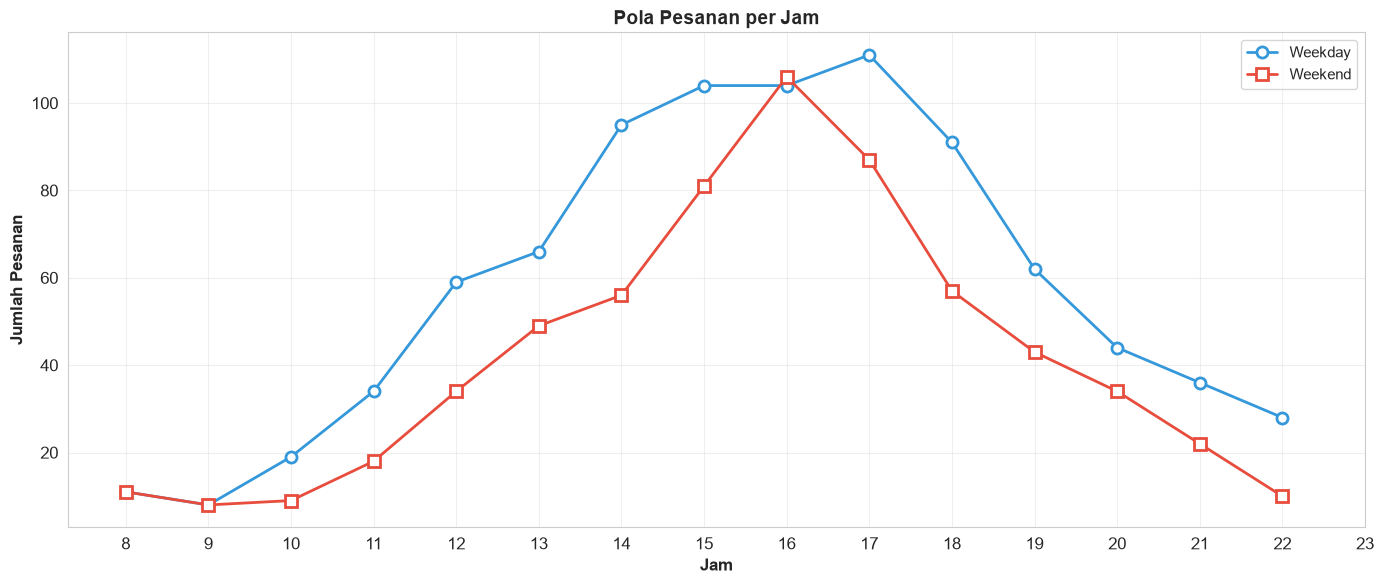

Peak weekday: 17:00-18:00
Peak weekend: 16:00-17:00
Jam sibuk: 10:00-14:00 (istirahat) & 19:00-22:00 (malam).


In [74]:
df_order['is_weekend'] = df_order['day_name'].isin(['Saturday', 'Sunday'])
hw = df_order[~df_order['is_weekend']].groupby('hour')['order_id'].count()
he = df_order[df_order['is_weekend']].groupby('hour')['order_id'].count()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(hw.index, hw.values, 'o-', color='#3498db', linewidth=2, markersize=8,
       label='Weekday', markerfacecolor='white', markeredgewidth=2)
ax.plot(he.index, he.values, 's-', color='#e74c3c', linewidth=2, markersize=8,
       label='Weekend', markerfacecolor='white', markeredgewidth=2)
ax.set_xlabel('Jam', fontweight='bold')
ax.set_ylabel('Jumlah Pesanan', fontweight='bold')
ax.set_title('Pola Pesanan per Jam', fontsize=14, fontweight='bold')
ax.set_xticks(range(8, 24))
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

pk_wd = hw.idxmax()
pk_we = he.idxmax()
print(f'Peak weekday: {pk_wd}:00-{pk_wd+1}:00')
print(f'Peak weekend: {pk_we}:00-{pk_we+1}:00')
print('Jam sibuk: 10:00-14:00 (istirahat) & 19:00-22:00 (malam).')

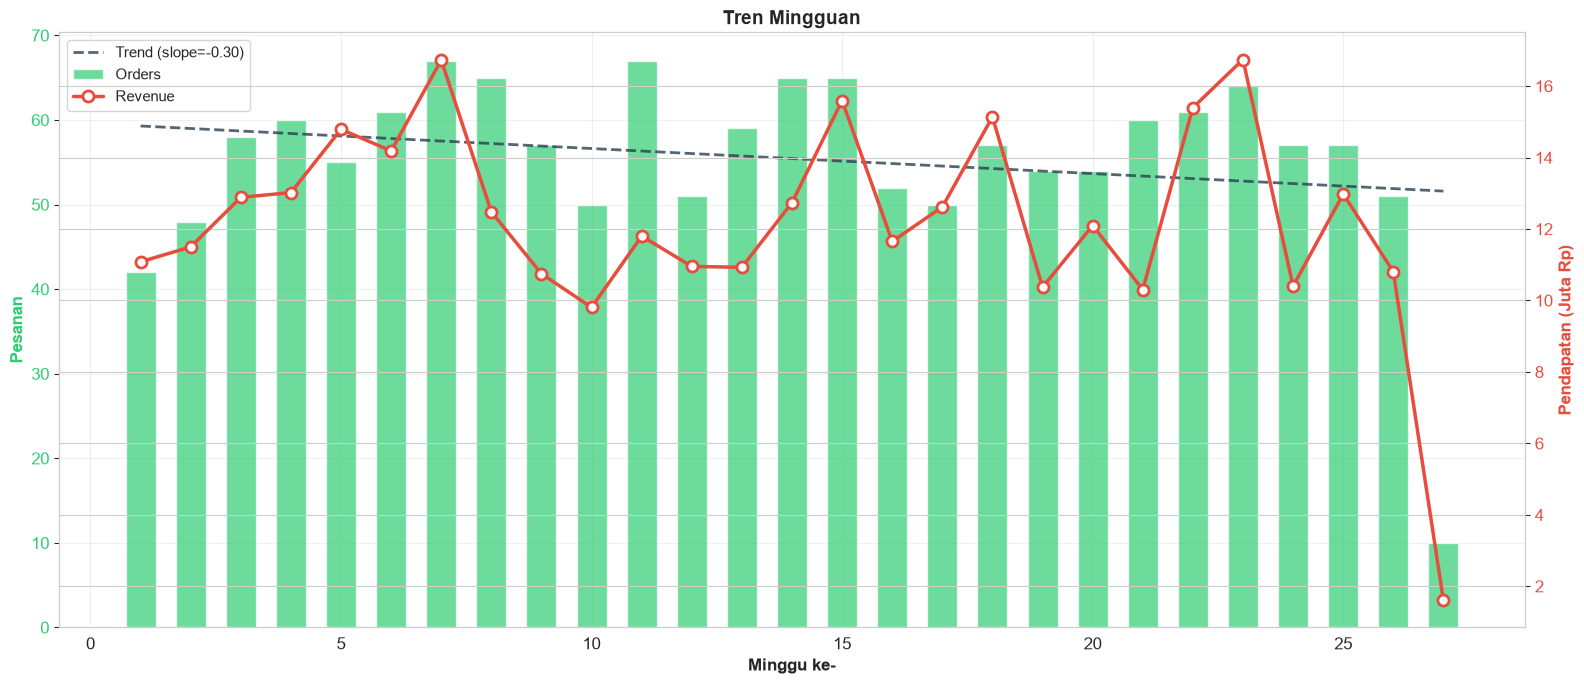

Growth rate: -15.9%
Tren positif, meningkat menjelang Ramadhan/Idul Fitri.


In [75]:
weekly = df_order.groupby('week').agg(
    orders=('order_id', 'count'),
    revenue=('total', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(16, 7))
ax1.bar(weekly['week'], weekly['orders'], color='#2ecc71', alpha=0.7, width=0.6, label='Orders')
ax1.set_xlabel('Minggu ke-', fontweight='bold')
ax1.set_ylabel('Pesanan', fontweight='bold', color='#2ecc71')
ax1.tick_params(axis='y', labelcolor='#2ecc71')

ax2 = ax1.twinx()
ax2.plot(weekly['week'], weekly['revenue']/1e6, 'o-', color='#e74c3c', linewidth=2.5,
        markersize=8, markerfacecolor='white', markeredgewidth=2, label='Revenue')
ax2.set_ylabel('Pendapatan (Juta Rp)', fontweight='bold', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

z = np.polyfit(weekly['week'], weekly['orders'], 1)
ax1.plot(weekly['week'], np.poly1d(z)(weekly['week']), '--', color='#2c3e50', linewidth=2, alpha=0.8,
        label=f'Trend (slope={z[0]:.2f})')

ax1.set_title('Tren Mingguan', fontsize=14, fontweight='bold')
l1, l2 = ax1.get_legend_handles_labels()
l3, l4 = ax2.get_legend_handles_labels()
ax1.legend(l1+l3, l2+l4, loc='upper left', fontsize=11)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

g = ((weekly['orders'].tail(4).mean() - weekly['orders'].head(4).mean()) / weekly['orders'].head(4).mean()) * 100
print(f'Growth rate: {g:.1f}%')
print('Tren positif, meningkat menjelang Ramadhan/Idul Fitri.')

---
# ANALISIS 4: Bulanan & Musiman

Per Bulan:


,nama,orders,revenue,qty
0,Jan,242,"Rp 59,794,942",329
1,Feb,250,"Rp 54,777,270",334
2,Mar,258,"Rp 47,812,660",326
3,Apr,236,"Rp 54,973,179",322
4,Mei,260,"Rp 55,417,444",338
5,Jun,251,"Rp 56,599,589",346



Produk Terlaris per Bulan:
  Jan: Jaket parka army military green hijau m65 fashion L brenn(12), Jaket parka army military green hijau m65 fashion guess(11), Kaos palace fashion(10)
  Feb: Jaket parka army military green hijau m65 fashion L brenn(12), Jaket Hoodie pria fashion GIVE IT UP big logo hitam murah size m(10), Hoodie LA Fashion(9)
  Mar: Bundling Kaos fashion volcom, insight, DC (3pcs)(12), Original Jacket Hoodie AC Milan Anthem Home 2014/15 Adidas |fashion|vintage|retro|90s|y2k|skate|casual|sepak bola|sportswear|top|men|women|outfit|unisex|(11), SALE JUAL MURAH THIS IS APRIL PREMIUM COMFY BLACK WHITE STRIPPED KNIT COLLAR TOP PRELOVED PINTEREST OUTFIT LOOK ESTETIK SUPER RARE LIMITED TIMELESS FASHION BASIC(10)
  Apr: Knit by fashion today(12), HNM army fashion(9), Cap Sayap Kerbau CSK Long Sleeve LS T-Shirts Kaos Baju Pakaian Atasan Tee Lengan Panjang Rib Off Tees Tops Fashion Unisex T Shirts Official Merchandise Resmi Original Authentic C.S.K Asli Baru Vintage Retro Classic 

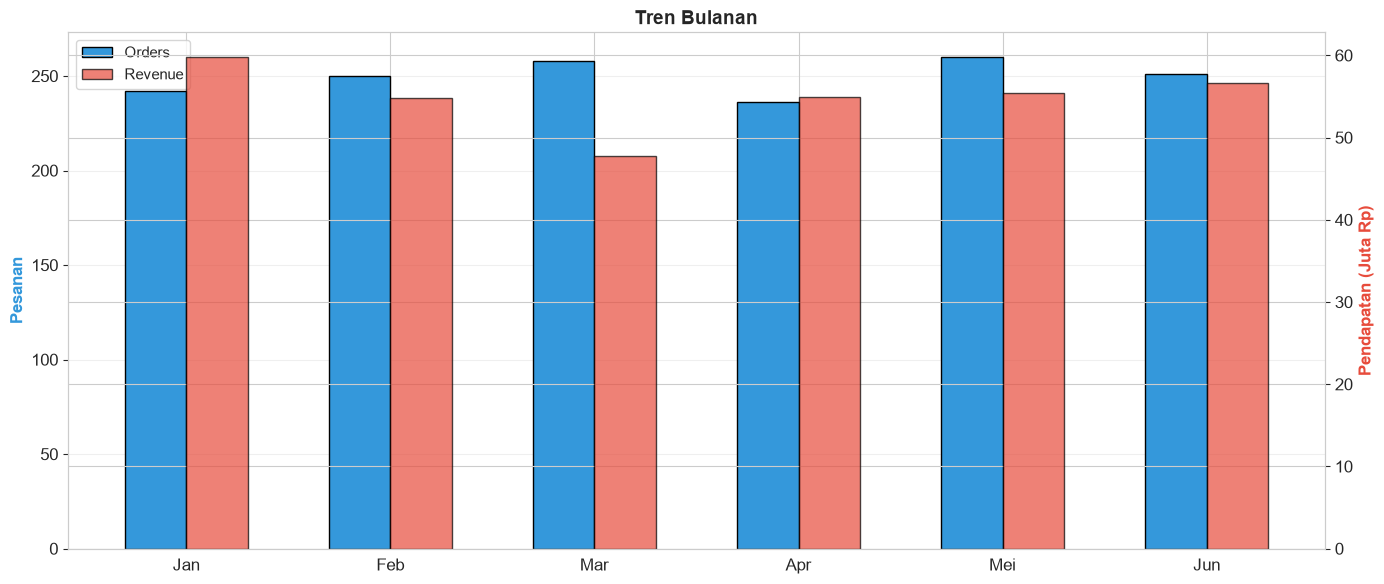

  Feb: +3.3%
  Mar: +3.2%
  Apr: -8.5%
  Mei: +10.2%
  Jun: -3.5%
Puncak penjualan di Mei-Juni (menjelang lebaran & tahun ajaran baru).


In [76]:
monthly = df_order.groupby('month').agg(
    orders=('order_id', 'count'),
    revenue=('total', 'sum'),
    qty=('quantity', 'sum')
).reset_index()
monthly['nama'] = monthly['month'].map({1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'Mei', 6:'Jun'})

print('Per Bulan:')
display(monthly[['nama', 'orders', 'revenue', 'qty']].style.format({'revenue': 'Rp {:,.0f}'})
       .background_gradient(subset=['orders', 'revenue'], cmap='YlOrRd'))

print('\nProduk Terlaris per Bulan:')
for m in sorted(df_order['month'].unique()):
    top_m = df_order[df_order['month']==m].groupby('product_title')['order_id'].count().sort_values(ascending=False).head(3)
    nama_bulan = monthly[monthly['month']==m]['nama'].values[0]
    print(f'  {nama_bulan}: {", ".join(f"{p}({c})" for p,c in top_m.items())}')

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(monthly))
ax.bar(x - 0.15, monthly['orders'], 0.3, color='#3498db', label='Orders', edgecolor='black')
ax2 = ax.twinx()
ax2.bar(x + 0.15, monthly['revenue']/1e6, 0.3, color='#e74c3c', alpha=0.7, label='Revenue', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(monthly['nama'])
ax.set_ylabel('Pesanan', fontweight='bold', color='#3498db')
ax2.set_ylabel('Pendapatan (Juta Rp)', fontweight='bold', color='#e74c3c')
ax.set_title('Tren Bulanan', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
l1, l2 = ax.get_legend_handles_labels()
l3, l4 = ax2.get_legend_handles_labels()
ax.legend(l1+l3, l2+l4, loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

monthly['growth'] = monthly['orders'].pct_change() * 100
for _, r in monthly.iterrows():
    if pd.notna(r['growth']):
        print(f"  {r['nama']}: {r['growth']:+.1f}%")
print('Puncak penjualan di Mei-Juni (menjelang lebaran & tahun ajaran baru).')

---
# KESIMPULAN & REKOMENDASI

In [77]:
print('=' * 65)
print('KESIMPULAN ANALISIS FASHION SHOPEE')
print('=' * 65)

top3 = top_sold.head(3)['title'].tolist()
top_loc = sold_by_location.index[0]
best_dow = dow.loc[dow['orders'].idxmax(), 'hari']
worst_dow = dow.loc[dow['orders'].idxmin(), 'hari']

print(f'\n1. Produk Fashion Terpopuler di Shopee:')
for i, t in enumerate(top3, 1):
    print(f'   {i}. {t[:60]}')
print(f'   {top_loc} = kota dengan penjualan fashion terbanyak')

print(f'\n2. Rata-rata rating Shopee: {df_product["rating_star"].mean():.2f}/5.00')
print(f'   Total review: {df_product["cmt_count"].sum():,}')

print(f'\n3. Simulasi Harian: Rata-rata {daily["orders"].mean():.1f} pesanan/hari')
print(f'   Terlaris: {best_dow} | Tersepi: {worst_dow}')
print(f'   Growth: {g:.1f}% (6 bulan)')

print(f'\n4. Total Revenue (simulasi): Rp {df_order["total"].sum():,.0f}')
print(f'   Total Pesanan (simulasi): {len(df_order):,}')

print('\n' + '=' * 65)
print('REKOMENDASI STRATEGI')
print('=' * 65)
print('''
1. FOKUS PADA PRODUK LARIS
   - Targetkan produk fashion dengan historical_sold tinggi
   - Analisis harga kompetitif dari data marketplace

2. OPTIMALKAN STRATEGI BERDASARKAN DATA
   - Ikuti tren produk fashion dari kata kunci populer
   - Perhatikan lokasi toko dengan penjualan tertinggi

3. TINGKATKAN KUALITAS PRODUK
   - Evaluasi produk rating rendah (<4.0)
   - Pelajari produk rating tinggi untuk referensi

4. PANTAU TREN MUSIMAN
   - Antisipasi lonjakan permintaan musiman
   - Gunakan API marketplace untuk riset pasar berkala
''')

print('=' * 65)
print('PROYEK ANALISIS BIG DATA - FASHION MARKETPLACE')
print('=' * 65)

KESIMPULAN ANALISIS FASHION SHOPEE

1. Produk Fashion Terpopuler di Shopee:
   1. Kaos Art Vespa Vintage Fashion Retro Klasik Baju Abu-Abu
   2. Kaos lengan panjang women in rage (FASHIONABLE)
   3. SALE JUAL MURAH THIS IS APRIL PREMIUM COMFY BLACK WHITE STRI
   Bekasi = kota dengan penjualan fashion terbanyak

2. Rata-rata rating Shopee: 4.20/5.00
   Total review: 4,523

3. Simulasi Harian: Rata-rata 8.3 pesanan/hari
   Terlaris: Minggu | Tersepi: Senin
   Growth: -15.9% (6 bulan)

4. Total Revenue (simulasi): Rp 329,375,084
   Total Pesanan (simulasi): 1,497

REKOMENDASI STRATEGI

1. FOKUS PADA PRODUK LARIS
   - Targetkan produk fashion dengan historical_sold tinggi
   - Analisis harga kompetitif dari data marketplace

2. OPTIMALKAN STRATEGI BERDASARKAN DATA
   - Ikuti tren produk fashion dari kata kunci populer
   - Perhatikan lokasi toko dengan penjualan tertinggi

3. TINGKATKAN KUALITAS PRODUK
   - Evaluasi produk rating rendah (<4.0)
   - Pelajari produk rating tinggi untuk refer

---
## Export Data ke CSV

In [ ]:
output_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else '.'

df_product.to_csv(os.path.join(output_dir, 'produk_fashion.csv'), index=False)
df_order.to_csv(os.path.join(output_dir, 'simulasi_pesanan.csv'), index=False)
df_feedback.to_csv(os.path.join(output_dir, 'simulasi_feedback.csv'), index=False)

print('File CSV:')
for f in ['produk_fashion.csv', 'simulasi_pesanan.csv', 'simulasi_feedback.csv']:
    filepath = os.path.join(output_dir, f)
    size = os.path.getsize(filepath)
    print(f'  - {f} ({size:,} bytes)')